In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch

plt.rcParams.update({
    'font.size': 20,
    'font.family': 'Nimbus Sans'})

class yeast_geno_data:
    def __init__(self, geno_data_path, ids_path, snp_info_path, 
                 gene_info_path, gpu_device='cuda:0'):
        self.geno = np.load(geno_data_path)
        self.geno_t = torch.tensor(self.geno).to(gpu_device)
        self.ids = np.loadtxt(ids_path, delimiter='\t', dtype='int')
        self.snp_info = pd.read_csv(snp_info_path, delimiter='\t', index_col=0)
        self.gene_info = pd.read_csv(gene_info_path)
        self.L = self.geno.shape[1]
        
    def sub_sample_snps(self, r2_threshold):
        lim  = self.L
        loci = [0]
        i = 0
        while i < lim:
            j = i + 1
            while (j < lim) and (torch.corrcoef(
                geno_data.geno_t[:, [i, j]].t())[0, 1]**2 >= r2_threshold):       
                j += 1
            if j < lim:
                i = j
                loci.append(i)
            else: break
        self.loci_chosen = loci
        self.abs_pos = {locus: get_abs_pos(*list(geno_data.snp_info.loc[locus][['Chromosome', 'Position (bp)']])) for locus in self.loci_chosen}

    def get_geno(self, snps):
        return self.geno[:, snps]
    
    # def get_gene_info(self, gene_name):
    #     return self.gene_info[self.gene_info.Standard_name == gene_name]

class yeast_fitness_data():
    def __init__(self, treatment, conditions, in_path):
        self.treatment = treatment
        self.conditions = conditions
        self.in_path = in_path

        
    def load_condition(self, condition, fitness):        
        dfs = [pd.read_csv(self.in_path / f'fitness/{condition}_{rep}.tsv').set_index('Number') for rep in [1, 2, 3]]

        df_reps = pd.concat(dfs, axis=1, join='outer')
        df_reps['Idx'] = df_reps.index

        # df_fit = df_reps[fitness].dropna()
        df_fit = df_reps[fitness].copy()
        df_fit = df_fit
        df_fit['mean_log_fit'] = df_fit.mean(1)
        df_fit['std_log_fit'] = df_fit.std(1)
        
        return df_fit
    
    def load_all_conditions(self, fitness, sub=None):
        df_fits = {}
        for condition in self.conditions:
            df_fits[condition] = self.load_condition(condition, fitness)
            
        self.df_fits_all = pd.concat(list(df_fits.values()), axis=1, join='outer')
        self.df_fits = self.df_fits_all[['mean_log_fit', 'std_log_fit']]
        if len(sub) == 0:
            pass
        else: self.df_fits = self.df_fits[sub]
        
    def get_fit_data(self, ids, dropna=True):
        
        if dropna:
            data = self.df_fits.loc[ids].dropna()
        else: data = self.df_fits.loc[ids]
        
        return data


import statsmodels.formula.api as smf
import statsmodels.api as sm
class yeast_data():
    def __init__(self, geno_data, fitness_data):
        self.geno_data = geno_data
        self.fitness_data = fitness_data
        
        self.ids = set(self.geno_data.ids).intersection(list(self.fitness_data.df_fits.index))
        self.ids = list(self.ids)
        self.ids.sort()
        self.ids_geno_pos = np.where(np.isin(self.geno_data.ids, self.ids))[0]
        
        self.geno = self.geno_data.geno[self.ids_geno_pos]
        self.fitness = self.fitness_data.df_fits.loc[self.ids]
        
        self.cat_to_con = dict(enumerate(self.fitness_data.conditions))
        self.con_to_cat = {v:k for k, v in self.cat_to_con.items()}
        self.con_to_num = {'C': 0, 'Q': .25, 'H': .5, 'F': 1, 'D': 2}
        self.num_to_con = {v:k for k, v in self.con_to_num.items()}
        
        
    def calc_snp_effect(self, locus):
        mean_fit_BY = self.fitness[data.geno[:, locus] == 0]['mean_log_fit'].mean(0) 
        mean_fit_RM = self.fitness[data.geno[:, locus] == 1]['mean_log_fit'].mean(0)
        diff = mean_fit_BY - mean_fit_RM
        diff.index = self.fitness_data.conditions
        return diff
    
    def get_main_effects(self, loci):
        main_effects = {}
        for locus in loci:
            main_effects[locus] = self.calc_snp_effect(locus)
        return pd.DataFrame(main_effects).T
    
    def stack_data(self, conditions_test):
        self.conditions_test = conditions_test
        conditions_test = pd.Series(conditions_test)

        col_idx = conditions_test.map(self.con_to_cat).tolist()
        self.fitness_stacked = np.array(self.fitness['mean_log_fit'].iloc[:, col_idx]).reshape(-1)
        self.std_stacked = np.array(self.fitness['std_log_fit'].iloc[:, col_idx]).reshape(-1)
        conditions_test_ = conditions_test.map(self.con_to_num).tolist()
        self.cons = np.array([conditions_test_ for _ in range(len(self.geno))]).flatten()

    def calc_GxE_pvalue(self, locus):
        
        X = self.geno[:, locus]
        X_ = np.repeat(X, len(self.conditions_test)).flatten()

        df_data = pd.DataFrame({
            "fitness": self.fitness_stacked,
            "condition": self.cons,
            "genotype": X_,
            "sigma": self.std_stacked
        })

        df_data = df_data.dropna()    
        # df_data = df_data[df_data.sigma < df_data.sigma.quantile(.2)]
        # df_data = df_data[df_data.sigma < df_data.sigma.quantile(.25)]        
        model_wls = smf.wls("fitness ~ genotype + condition + genotype * condition", data=df_data).fit()
        # pvalue = model_wls.pvalues['genotype:condition']

        anova_results = sm.stats.anova_lm(model_wls, typ=2)
        pvalue = anova_results.loc['genotype:condition']['PR(>F)']        
        coef = model_wls.params['genotype:condition']
        
        return pvalue, coef
    
    
yeast_chr_lengths = [
    230218, 813184, 316620, 1531933, 576874, 270161, 1090940, 562643,
    439888, 745751, 666816, 1078177, 924431, 784333, 1091291, 948066
]
yeast_chr_size = np.array(yeast_chr_lengths).sum()

chr_labels_arabic = [str(i) for i in range(1, 17)]
chr_offsets = np.cumsum([0] + yeast_chr_lengths[:-1])

def get_abs_pos(chrom, chrom_pos):
    return (chrom_pos - 1) + dict(enumerate(chr_offsets))[chrom - 1]    


from matplotlib.patches import Rectangle
import matplotlib.transforms as transforms

def make_man(abs_pos, y, ylab, df_lab=None, chrom=None, chrom_range=None, constrained_layout=False):

    plt.rcParams.update({
        'font.size': 24,
        'font.family': 'Nimbus Sans'  # options: 'serif', 'sans-serif', 'monospace', etc.
    })

    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=constrained_layout)
    
    ax.bar(
        abs_pos,
        y,
        width=20000,
        color='black'
    )
    ax.margins(x=0.05, y=0.2)
    
    if df_lab is None:
        pass
    else:
        for _, row in df_lab.iterrows():
            name = row.iloc[2]
            x, y = row.iloc[:2]
            if y > 0:
                y_offset = 5
            else: 
                y_offset = -7
            ax.annotate(
                name,
                xy=(x, y),  # arrow tip
                xytext=(0, y_offset),                  # offset in points above the bar
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=10, 
                color='red',
                # arrowprops=dict(arrowstyle="->", color="red")
            )
    # Draw vertical lines for chromosome boundaries
    for offset in chr_offsets[1:]:
        ax.axvline(offset, color='lightgray', lw=2, zorder=0)

    # Set x‐ticks at chromosome midpoints
    midpoints = [offset + length/2 for offset, length in zip(chr_offsets, yeast_chr_lengths)]
    ax.set_xticks(midpoints)
    ax.set_xticklabels(chr_labels_arabic, fontsize=12, fontweight='bold')
    
    if chrom is None:
        ax.set_xlim(0, yeast_chr_size)
            
    else:
        if chrom_range is None:        
            ax.set_xlim(chr_offsets[chrom], chr_offsets[chrom + 1])
        else:
            ax.set_xlim(chr_offsets[chrom] + chrom_range[0], chr_offsets[chrom] + chrom_range[1])

    ax.set_xlabel('Chromosome', fontsize=18)
    ax.set_ylabel(f'{ylab}', fontsize=18)
    ax.margins(x=0)

    return fig, ax


def add_labels(ax, name, x, y, color):

    df_lab = pd.DataFrame({'name': name, 'x': x, 'y': y})
    for _, row in df_lab.iterrows():
        name = row.iloc[0]
        x, y = row.iloc[1:]
        if y > 0:
            y_offset = 5
        else: 
            y_offset = -7
        ax.annotate(
            name,
            xy=(x, y),  # arrow tip
            xytext=(0, y_offset),                  # offset in points above the bar
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=14, 
            color=color,
            # arrowprops=dict(arrowstyle="->", color="red")
        )
    return ax

In [2]:
# load genotype data

path = Path("/orange/juannanzhou/MarginalEpistasis/data/")
geno_data_path = path / "geno_top_25.npy"
ids_path = path / "index_top_25.tsv"
snp_info_path = "./data/snp_info_complete.tsv"
gene_info_path = "./data/gene_info.csv"

geno_data = yeast_geno_data(geno_data_path, ids_path, snp_info_path, gene_info_path)
geno_data.sub_sample_snps(r2_threshold=.99)

r2_mat = torch.corrcoef(geno_data.geno_t[:, geno_data.loci_chosen[:]].t())**2
r2_mat = r2_mat.cpu().numpy()

# load fitness data
conditions = ['C', 'Q', 'H', 'F']
treatment = 'Fluconazole'
in_path = Path(f'/orange/juannanzhou/juannanzhou/BBQTL-HT/{treatment}/results')
p0_counts = pd.read_csv(in_path / "fitness/F_1.tsv")['P0']
p0_freqs = p0_counts/p0_counts.sum(0)
sub = p0_freqs > 10**-5
print(f'number of genotypes chosen = {sub.sum()}')

fitness_data = yeast_fitness_data(treatment, conditions, in_path)
fitness_data.load_all_conditions('log_fitness1', sub=sub)

# combine genotype and phenotype data
data = yeast_data(geno_data, fitness_data)

main_effects = data.get_main_effects(geno_data.loci_chosen)

number of genotypes chosen = 27685


In [3]:
# sub = p0_freqs > 10**-6
# plotdata = fitness_data.load_condition('H', 'log_fitness1')[sub].dropna().iloc[:, [0, 2]]

# plt.scatter(plotdata.iloc[:, 0], plotdata.iloc[:, 1], color='black', alpha=.05)

# # Compute Pearson r²
# r = np.corrcoef(plotdata.iloc[:, 0], plotdata.iloc[:, 1])[0, 1]
# r2 = r**2

# # Add text in top-left corner
# plt.text(0.05, 0.95, f"$R^2 = {r2:.2f}$",
#          transform=plt.gca().transAxes,
#          ha="left", va="top")

# # Labels
# plt.xlabel("Fitness rep. 1")
# plt.ylabel("Fitness rep. 2")
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
# plt.xticks([-4, -2, 0, 2, 4])
# plt.yticks([-4, -2, 0, 2, 4])
# plt.title("Fluconazle (0.5 MIC)")

# # Aspect ratio = 1
# plt.gca().set_aspect("equal", adjustable="box")

# plt.savefig("figures/scatter_plot_across_reps.png", bbox_inches="tight")
# plt.show()

In [4]:
data.stack_data(['C', 'H'])
# data.stack_data(['Q', 'H', 'F'])
# data.stack_data(['C', 'Q', 'H', 'F'])

results = {locus: data.calc_GxE_pvalue(locus) for locus in data.geno_data.loci_chosen}

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x14fd6c6cb0e0>>
Traceback (most recent call last):
  File "/blue/juannanzhou/juannanzhou/conda/envs/gpy4/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt



In [ ]:
df_gxe = pd.DataFrame(results).T
df_gxe.columns = ['pvalue', 'coef']
df_gxe['abs_pos'] = data.geno_data.abs_pos.values()

print(f'number of snps with zero p-value = {len(df_gxe[df_gxe.pvalue == 0])}')

In [ ]:
pseudo_v = 1e-300
# pseudo_v = 0
df_gxe.pvalue = -1 * np.log10(df_gxe.pvalue + pseudo_v) # convert to negative log10

In [174]:
locus = 14179
X = data.geno[:, locus]
X_ = np.repeat(X, len(data.conditions_test)).flatten()

df_data = pd.DataFrame({
    "fitness": data.fitness_stacked,
    "condition": data.cons,
    "genotype": X_,
    "sigma": data.std_stacked
})

df_data = df_data.dropna()        

# df_data = df_data[df_data.sigma < df_data.sigma.quantile(.1)]

model_wls = smf.wls("fitness ~ genotype + condition + genotype * condition", data=df_data).fit()
# pvalue = model_wls.pvalues['genotype:condition']

anova_results = sm.stats.anova_lm(model_wls, typ=2)
pvalue = anova_results.loc['genotype:condition']['PR(>F)']        
coef = model_wls.params['genotype:condition']


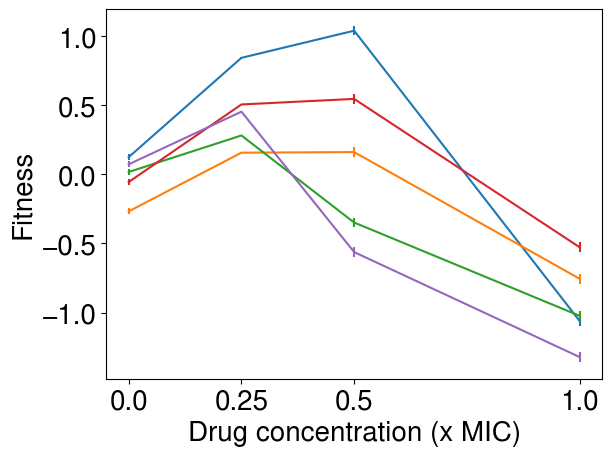

In [5]:
fitness = data.fitness

fitness = fitness.loc[fitness['std_log_fit'].mean(1).sort_values().index]

for i in [26, 38, 46, 66, 77]:
    plt.errorbar([0., .25, .5, 1.], np.array(fitness.iloc[i].mean_log_fit), np.array(fitness.iloc[0].std_log_fit), label=i)
# plt.legend(fontsize=10)
plt.xticks([0., .25, .5, 1.], [0., .25, .5, 1.])
plt.ylabel('Fitness')
plt.xlabel("Drug concentration (x MIC)")
# plt.savefig('figures/response_curves.pdf', bbox_inches="tight")
plt.show()

In [6]:
df_plot = df_gxe
genes = list(geno_data.snp_info.loc[df_plot.index].gene_standard_name)

df_plot['gene'] = genes

top_genes = df_plot.sort_values('pvalue', ascending=False).gene[:200].drop_duplicates().to_list()

NameError: name 'df_gxe' is not defined

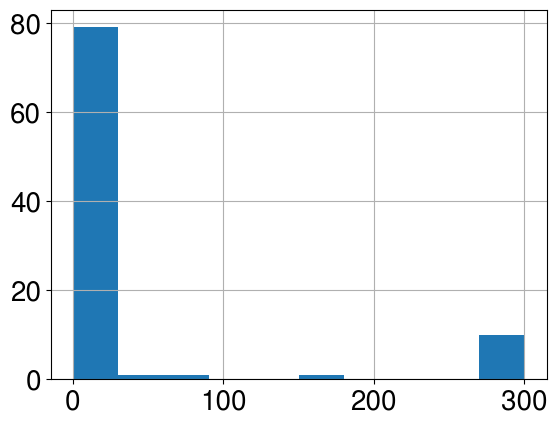

In [189]:
value = 'pvalue'

l = len(df_plot)

b = 20
local_max = []
for i in range(l):
    start, end = max(0, i - b), min(i + b + 1, l)    
    local_max.append(np.abs(df_plot[value].iloc[i]) == df_plot[value].iloc[start:end].abs().max())

df_plot_max = df_plot[local_max]
# df_plot_max = df_plot_max.drop_duplicates(subset=['gene'])
# df_plot_max = df_plot_max.drop_duplicates(subset=['effect'])
df_plot_max = df_plot[local_max]

df_plot_max[value].abs().hist()
plt.show()

# df_plot_max[df_plot_max.effect > 20].gene.drop_duplicates().to_csv("top_genes.txt", index=None, header=None)

In [190]:
genes_priortized = []

for pwy in df_enrich_top.index:
    genes_priortized = genes_priortized + list(pathway_info[pwy])

genes_priortized = list(set(genes_priortized))

print(f'number of genes in top KEGG pathways = {len(genes_priortized)}')

gene_mapped = []

for i in range(len(df_plot_max)):
    pos = df_plot_max.iloc[i]['abs_pos']
    gene_info_ = gene_info.copy()
    gene_info_ = gene_info_[[g in genes_priortized for g in gene_info_.index]]
    gene_info_['dist_to_snp'] = np.abs(gene_info_.start_abs - pos)
    gene_info_ = gene_info_.sort_values(by='dist_to_snp')
    
    if gene_info_.dist_to_snp.min() < 10000: 
        gene_mapped.append(gene_info_.index[0])
    else: gene_mapped.append(df_plot_max.gene.iloc[i])

df_plot_max['gene_kegg'] = gene_mapped

number of genes in top KEGG pathways = 176


/blue/juannanzhou/juannanzhou/conda/envs/gpy3/lib/python3.7/site-packages/ipykernel/__main__.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [191]:
gene_highlights = pd.read_csv("fluconazole_genes.txt", header=None).iloc[:, 0].tolist()

poss = []
for gene in gene_highlights:
    try:
        pos = np.where(np.array(df_plot.gene) == gene)[0][0]
        poss.append(pos)
    except: pass

df_plot_known_genes = df_plot.iloc[poss]

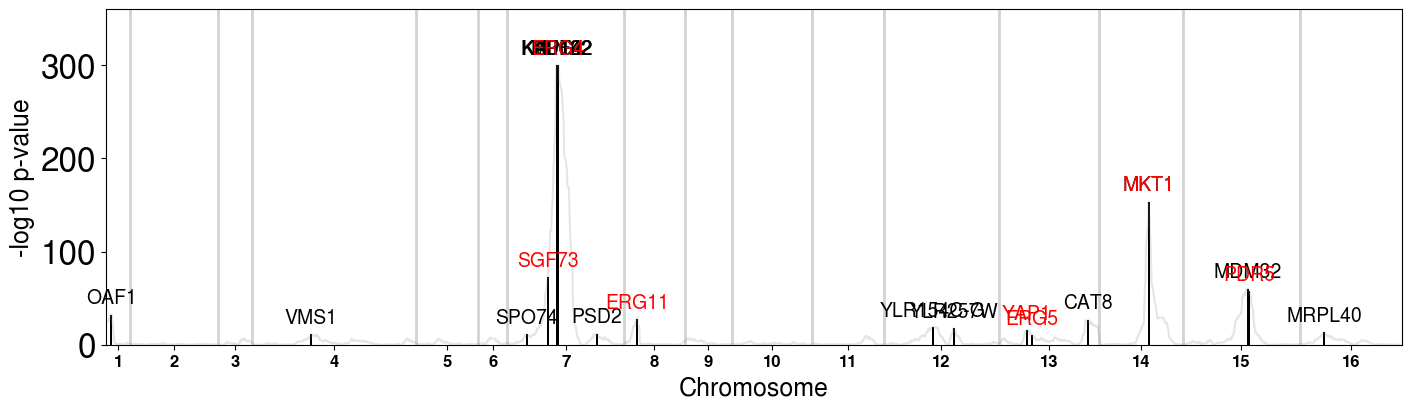

In [193]:
genes_to_exclude = []

threshold = 10

df_plot_max = df_plot_max[df_plot_max[value].abs() > threshold]
df_plot_known_genes = df_plot_known_genes[df_plot_known_genes[value] > threshold]

df_plot_bars = pd.concat([df_plot_max, df_plot_known_genes])

fig, ax = make_man(df_plot_bars.abs_pos, df_plot_bars[value], ylab='-log10 p-value', constrained_layout=True)

genes_to_exclude = ["PDR1", "YHR007C-A", "VRL1", "RUP1", 'MET4', 'PDR5', 'ERG11', 'RPB2', 'GLE2', 'UFO1']

df_plot_max = df_plot_max[[gene not in set(genes_to_exclude) for gene in df_plot_max.gene]]

df_plot_bg = df_plot_max.copy()
df_plot_bg = df_plot_bg[df_plot_bg[value].abs() > 1. * threshold]
ax = add_labels(ax, 
                # df_plot_bg['gene_kegg'], 
                df_plot_bg['gene'],                 
                df_plot_bg['abs_pos'], 
                df_plot_bg[value], 
                'black')

ax = add_labels(ax, 
                df_plot_known_genes['gene'], 
                df_plot_known_genes['abs_pos'], 
                df_plot_known_genes[value], 
                'red')

# Plot blue line for –log(p)
ax.plot(
    df_plot['abs_pos'],
    df_plot[value],
    color='gray',
    lw=1.5,
    zorder=2, 
    alpha=.2
)

plt.savefig('figures/man_plot.pdf', bbox_inches="tight")

plt.show()

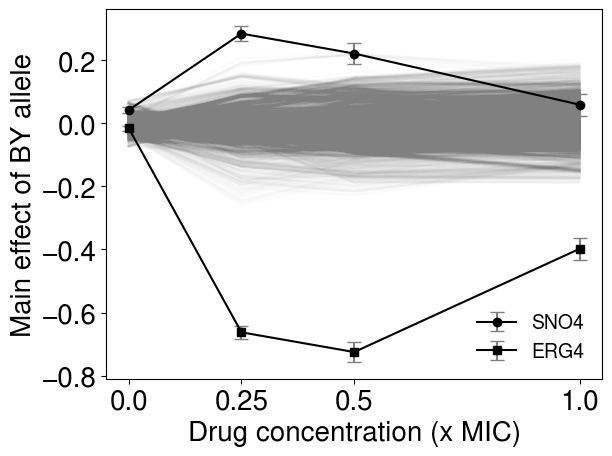

In [7]:
def geneate_main_effect_plot_data(locus, data):
    main_effects_samples = []

    for _ in range(1000):

        df_BY = data.fitness[data.geno[:, locus] == 0]['mean_log_fit']
        df_RM = data.fitness[data.geno[:, locus] == 1]['mean_log_fit']

        diff =  df_BY.sample(n=1000, replace=True).mean(0) - df_RM.sample(n=1000, replace=True).mean(0)

        main_effects_samples.append(diff)

    main_effects_samples = pd.concat(main_effects_samples, axis=1).T  
    
    plotdata = pd.DataFrame({
                    "condition": [0, .25, .5, 1], 
                    # "condition": conditions, 
                    "mean_effect": main_effects_samples.mean(0), 
                    "std": main_effects_samples.std(0)})

    return plotdata

locus = 33570
plotdata = geneate_main_effect_plot_data(locus, data)
plt.errorbar(
    plotdata['condition'], plotdata['mean_effect'],
    yerr=plotdata['std'],
    fmt='o-',         # Markers ('o') connected by a line ('-')
    capsize=5,        # Small horizontal caps on the error bars
    color='black',
    ecolor='gray',    # Error bar color
    markerfacecolor='black',
    markeredgecolor='black', 
    label='SNO4'
)

locus = 14442
plotdata = geneate_main_effect_plot_data(locus, data)
plt.errorbar(
    plotdata['condition'], plotdata['mean_effect'],
    yerr=plotdata['std'],
    fmt='s-',         # Markers ('o') connected by a line ('-')
    capsize=5,        # Small horizontal caps on the error bars
    color='black',
    ecolor='gray',    # Error bar color
    markerfacecolor='black',
    markeredgecolor='black', 
    label='ERG4'
)

threshold = main_effects.var(1).quantile(.90)
plotdata_bg = main_effects[main_effects.var(1) < threshold]
plotdata_bg.columns = [0., .25, .5, 1.]
plt.plot(plotdata_bg.T, color='gray', alpha=.01)

plt.xticks([0., .25, .5, 1.], [0., .25, .5, 1.])
plt.legend(fontsize=14, frameon=False)
plt.ylabel('Main effect of BY allele')
plt.xlabel("Drug concentration (x MIC)")

# plt.savefig('figures/main_effect_changes.pdf', bbox_inches="tight")
plt.show()

### SGD pathway enrichment

In [237]:
import gseapy as gp
from scipy.interpolate import make_interp_spline

def filter_gene_set(gene_set):
    return gene_set[[g in list(gene_info.index) for g in gene_set]]    

def get_gene_scores(gene_set):
    values = gene_info.loc[gene_set].pvalue_imputed
    return pd.Series(dict(zip(gene_set, values)))
    # return pd.Series(dict(zip(gene_set, values))), np.sum(values > 20) / len(values)    

# def get_stat(gene_set):
#     return get_gene_scores(gene_set).mean()

def get_stat(gene_set, threshold=20):
    res = get_gene_scores(gene_set)
    return (np.array(res) > 20).sum()/len(res)

from scipy import stats

def get_p_null(gene_set, draws=10000):
    n_genes = len(gene_set)
    global stats_null, stat_test
    stat_test = get_stat(gene_set)
    
    stats_null = []
    
    for _ in range(draws):
        stat = get_stat(np.random.choice(gene_info.index, n_genes))
        stats_null.append(stat)
    
    pct = stats.percentileofscore(stats_null, stat_test, kind='weak')

    return 1 - pct/100
    # return score_test, scores_null    

In [242]:
pathways = []
for root, dirs, files in os.walk('SGD_pathways/'):
    for filename in files:
        pathways.append(filename.split(".")[0])

In [244]:
pathways = pathways[:-2]

In [246]:
# pathway_info = {}
# for pwy in pathways: 
#     info = {}
#     with open(f"SGD_pathways/{pwy}.txt", "r") as f:
#         info["name"] = f.readline().strip()
#         info['genes'] = pd.read_csv(f, skiprows=1, sep='\t')
#     pathway_info[pwy] = info
    

pathway_info = {}
for pwy in pathways: 
    with open(f"SGD_pathways/{pwy}.txt", "r") as f:
        name = f.readline().strip()
        pathway_df = pd.read_csv(f, skiprows=1, sep='\t')
        genes = list(pathway_df['Gene name'])
        genes = list(set(genes).intersection(gene_info.index))
    pathway_info[name] = genes


In [247]:
pwy_stats = {}
for pwy in list(pathway_info.keys()):
    genes = list(pathway_info[pwy])
    genes = list(set(genes).intersection(gene_info.index))
    if len(genes) < 5:
        pass
    else:
        pwy_stats[pwy] = get_stat(genes)

In [248]:
n_tests = len(pwy_stats)

In [251]:
df_enrich = pd.DataFrame({"stat": pwy_stats})
df_enrich = df_enrich.sort_values(by='stat', ascending=False)
df_enrich_top = df_enrich.iloc[:20]
df_enrich_top

,stat
zymosterol biosynthesis,0.600000
ubiquinol-6 biosynthesis from 4-hydroxybenzoate (eukaryotic),0.400000
NAD salvage pathway V (PNC V cycle),0.333333
ergosterol biosynthesis,0.285714
superpathway of ubiquinone biosynthesis,0.250000
superpathway of TCA cycle and glyoxylate cycle,0.230769
"superpathway of fatty acid biosynthesis, saturated and unsaturated",0.222222
inosine-5'-phosphate biosynthesis I,0.200000
thiamine biosynthesis,0.200000
ergosterol biosynthesis I,0.200000


In [252]:
p_nulls = []

for i in range(20):

    pwy = df_enrich.index[i]
    gene_set = pathway_info[pwy]
    p_nulls.append(get_p_null(gene_set))

In [253]:
df_enrich_top['p_empirical'] = p_nulls
df_enrich_top['p_corrected'] = p_nulls * np.array(n_tests)

/blue/juannanzhou/juannanzhou/conda/envs/gpy3/lib/python3.7/site-packages/ipykernel/__main__.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == "__main__":
/blue/juannanzhou/juannanzhou/conda/envs/gpy3/lib/python3.7/site-packages/ipykernel/__main__.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


In [254]:
df_enrich_top

,stat,p_empirical,p_corrected
zymosterol biosynthesis,0.600000,0.0003,0.0165
ubiquinol-6 biosynthesis from 4-hydroxybenzoate (eukaryotic),0.400000,0.0055,0.3025
NAD salvage pathway V (PNC V cycle),0.333333,0.0110,0.6050
ergosterol biosynthesis,0.285714,0.0060,0.3300
superpathway of ubiquinone biosynthesis,0.250000,0.0253,1.3915
superpathway of TCA cycle and glyoxylate cycle,0.230769,0.0050,0.2750
"superpathway of fatty acid biosynthesis, saturated and unsaturated",0.222222,0.0407,2.2385
inosine-5'-phosphate biosynthesis I,0.200000,0.0644,3.5420
thiamine biosynthesis,0.200000,0.0641,3.5255
ergosterol biosynthesis I,0.200000,0.0618,3.3990


In [257]:
# CWI signaling

genes = list(pd.read_csv("CWI_pathway_genes.txt", header=None).iloc[:, 0])

genes = list(set(genes).intersection(gene_info.index))

print(get_stat(genes))

pvalue = get_p_null(gene_set)

0.18181818181818182


In [258]:
get_gene_scores(genes)

MID2      0.988676
WSC2      0.276064
SDP1      0.365264
SLT2      0.235455
MKK1      5.399517
SWI4      6.777436
MSG5     79.712865
RLM1      0.444744
BAG7     52.693215
ROM1     22.170393
PTP3      4.186689
ROM2      0.369277
WSC3     19.120068
BEM2      1.351454
SWI6      2.468643
PTP2     13.416864
LRG1      0.119770
BCK1      0.228805
MKK2      1.537203
PKC1      0.300842
RHO1      0.537621
MTL1    166.262738
dtype: float64